<a href="https://colab.research.google.com/github/Clinton1029/Bostonhousing1/blob/main/Bostonhousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Boston Housing Price Prediction Using Machine Learning

## Introduction

Accurately predicting house prices is an important task in the real estate industry, helping buyers, sellers, investors, and policymakers make informed decisions.

House prices are influenced by various factors such as crime rates, accessibility to highways, environmental conditions, property taxes, number of rooms, and neighborhood characteristics.

Machine learning provides powerful techniques for analyzing these relationships and predicting housing prices based on historical data.

## In this project, the **Boston Housing Dataset** is used to develop a machine learning regression model that predicts the median value of owner-occupied homes (**MEDV**) using 13 explanatory features.
---

## Problem Statement

Estimating the market value of residential properties is a challenging task because house prices depend on multiple socioeconomic, environmental, and structural factors. Traditional valuation methods often rely on manual assessments, which can be time-consuming and inconsistent. There is a need for an accurate and data-driven approach that can learn patterns from historical housing data and provide reliable price predictions.

This project aims to build a machine learning regression model capable of predicting the median value of homes using the Boston Housing Dataset. The developed model will help identify the most influential factors affecting housing prices while providing accurate price estimates for unseen data.

## Dataset Description

The Boston Housing Dataset is a well-known benchmark dataset used for regression analysis and machine learning. It contains information collected from various suburbs of Boston, Massachusetts, and is designed to predict the **median value of owner-occupied homes (MEDV)** based on several socioeconomic, environmental, and housing-related attributes.

The dataset consists of **506 observations (rows)** and **14 variables (columns)**. Among these variables, **13 are predictor (independent) features**, while **1 is the target (dependent) variable**.

### Dataset Features

| Feature | Description |
|----------|-------------|
| **CRIM** | Per capita crime rate by town. |
| **ZN** | Proportion of residential land zoned for lots over 25,000 square feet. |
| **INDUS** | Proportion of non-retail business acres per town. |
| **CHAS** | Charles River dummy variable (1 if tract bounds river; 0 otherwise). |
| **NOX** | Nitric oxides concentration (parts per 10 million). |
| **RM** | Average number of rooms per dwelling. |
| **AGE** | Proportion of owner-occupied units built prior to 1940. |
| **DIS** | Weighted distances to five Boston employment centers. |
| **RAD** | Index of accessibility to radial highways. |
| **TAX** | Full-value property tax rate per \$10,000. |
| **PTRATIO** | Pupil-teacher ratio by town. |
| **B** | A demographic variable calculated as \(1000(B_k - 0.63)^2\), where \(B_k\) is the proportion of Black residents by town. |
| **LSTAT** | Percentage of the lower-status population. |
| **MEDV** | Median value of owner-occupied homes in \$1,000s (Target Variable). |

### Target Variable

The target variable for this project is **MEDV**, which represents the median value of owner-occupied homes expressed in thousands of U.S. dollars. Since the objective is to predict a continuous numerical value, this project is classified as a **supervised machine learning regression problem**.

### Dataset Characteristics

- **Number of observations:** 506
- **Number of features:** 13
- **Target variable:** MEDV
- **Learning type:** Supervised Learning
- **Problem type:** Regression
- **Missing values:** The original dataset contains no missing values, although missing values may be introduced during preprocessing or experimentation.

# Project Workflow

The project will follow these steps:

1. Import Required Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing and Preparation
5. Feature Selection
6. Split the Dataset into Training and Testing Sets
7. Choose the Machine Learning Model
8. Train the Machine Learning Model
9. Make Predictions
10. Evaluate Model Performance
11. Hyperparameter Tuning
12. Predict House Prices for New Data


## 1. Import Required Libraries

In [8]:
# Import the Pandas library
import pandas as pd


# Import the Matplotlib library for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("/content/BostonHousing.csv")

## 3. Exploratory Data Analysis (EDA)

### 3.1 Display the first five rows

In [3]:
# Display the first five rows
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### 3.2  Display the last five rows

In [4]:
# Display the last five rows
df.tail()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


### 3.3 Display the shape of the dataset


In [5]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (506, 14)


### 3.4 Display dataset information


In [6]:
# Display dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### 3.5 Summary Statistics

In [7]:
# Display summary statistics
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 3.6 Distribution of the Target Variable (MEDV)


The distribution of the target variable (**MEDV**) is visualized using a histogram to examine how house prices are distributed across the dataset.

 This helps determine whether the target variable is normally distributed or exhibits skewness, which can influence the performance of regression models.

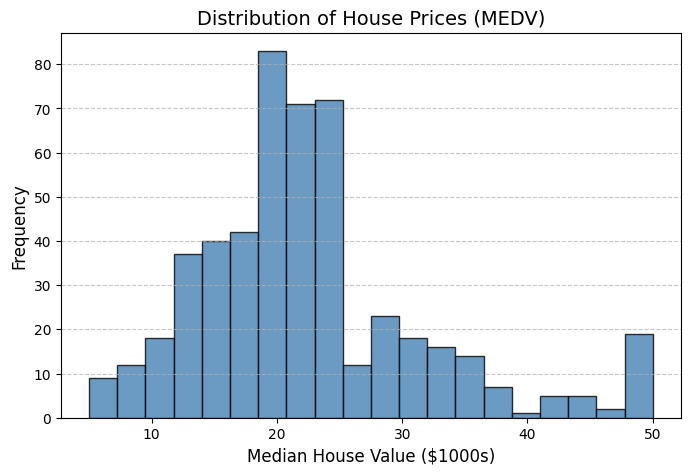

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["medv"],
    bins=20,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of House Prices (MEDV)", fontsize=14)
plt.xlabel("Median House Value ($1000s)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

###### Interpretation

The histogram shows that the **MEDV (Median House Value)** variable is concentrated between **\$15,000 and \$25,000**, indicating that most houses in the dataset fall within this price range. The distribution is **slightly right-skewed**, with relatively fewer houses having very high prices.



### 3.7 KDE (Kernel Density Estimation) Plots for Each Feature



Kernel Density Estimation (KDE) plots provide a smooth representation of the distribution of each numerical feature in the dataset.

Unlike histograms, KDE plots estimate the probability density of the data, making it easier to identify the shape of the distribution, detect skewness, observe multiple peaks (multimodality), and compare the spread of different variables.

These plots help in understanding the underlying distribution of each feature before building the machine learning model.

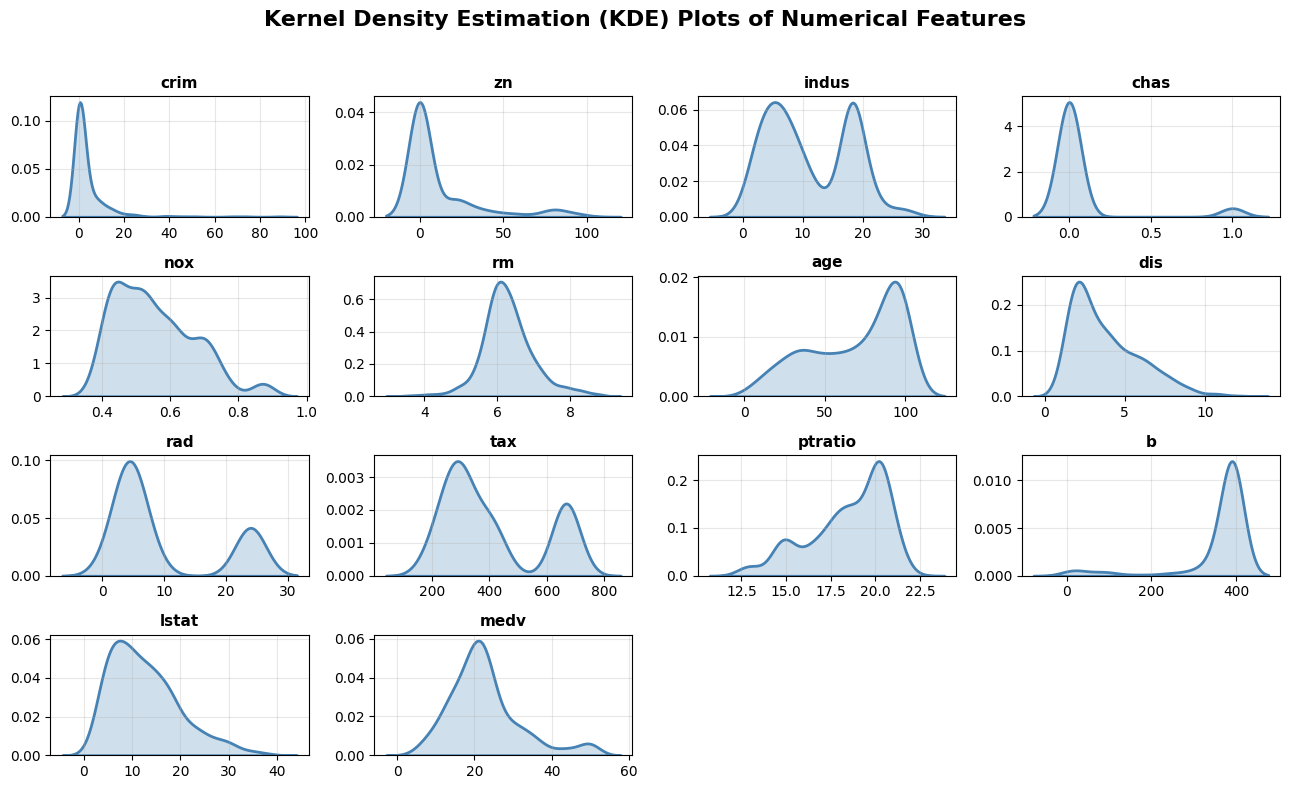

In [20]:
fig, axes = plt.subplots(4, 4, figsize=(13, 8))

axes = axes.flatten()

for i, column in enumerate(df.columns):
    sns.kdeplot(
        data=df,
        x=column,
        fill=True,
        color="steelblue",
        linewidth=2,
        ax=axes[i]
    )

    axes[i].set_title(column, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].grid(alpha=0.3)

# Remove any unused subplots
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Kernel Density Estimation (KDE) Plots of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

###### Interpretation

The KDE plots show the distribution of each numerical feature in the Boston Housing dataset.

 Most variables are **skewed** rather than normally distributed, indicating that observations are concentrated within specific ranges.

 Features such as **INDUS, RAD,** and **TAX** exhibit bimodal distributions, while **RM** is approximately normally distributed.

 The target variable (**MEDV**) is slightly right-skewed, with most house prices ranging between $15,000    and  $25,000 , and a noticeable peak at **$50,000**, reflecting the upper limit of house prices in the original dataset.

### 3.8 Boxplots

Boxplots are used to summarize the distribution of numerical features by displaying the median, quartiles, and potential outliers.

They provide a quick way to compare the spread and variability of different variables while identifying extreme values that may affect model performance.

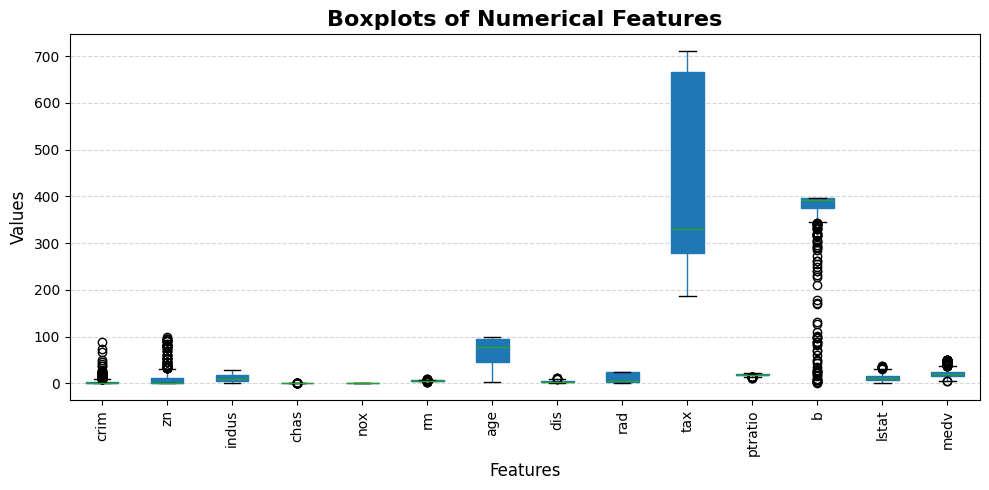

In [22]:
plt.figure(figsize=(10, 5))

df.boxplot(
    rot=90,
    patch_artist=True,
    grid=False
)

plt.title(
    "Boxplots of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

The boxplots indicate that several numerical features contain **outliers**, particularly **CRIM, ZN, RM, DIS, B, LSTAT,** and **MEDV**, as shown by the individual points beyond the whiskers.

Features such as **TAX** and **AGE** exhibit a wide range of values, indicating high variability across observations.

In contrast, variables like **CHAS** and **NOX** have relatively small spreads.

 Overall, the presence of outliers and varying distributions suggests that some features may require preprocessing or careful consideration during model development.